# Two-stage Unstain → virtual H&E: held-out WSI cohort test

학습과 동일한 slide-wise split을 재현하여 **8개 held-out WSI 전체**를 `2.0 MPP`에서 평가합니다. Stage 1과 Stage 2 모두 `latest.pt`를 사용합니다. 각 WSI의 원본 H&E를 저장된 affine matrix로 Unstain 좌표계에 정합하고, 타일 → 슬라이드 → 독립 case 순으로 집계합니다.

전체 83개 WSI가 아니라 held-out 8개만 기본 test cohort로 사용하는 이유는 학습 WSI가 test 결과에 섞이는 data leakage를 방지하기 위해서입니다.

In [1]:
from pathlib import Path

import torch
from IPython.display import Image as NotebookImage, display

from two_stage_inference import load_two_stage_models
from two_stage_wsi_batch_evaluation import run_heldout_wsi_evaluation
from wsi_publication_evaluation import PRIMARY_METRICS, discover_heldout_wsi

torch.set_grad_enabled(False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [2]:
DATA_DIR = Path('../../data/HnE_n_UNStaining/patch_dataset_mpp05_2048')
UNSTAIN_WSI_DIR = Path('../../data/HnE_n_UNStaining/Un-Stained-tiff')
HNE_WSI_DIR = Path('../../data/HnE_n_UNStaining/C_Stained-tiff')
REGISTRATION_DIR = Path('../../data/HnE_n_UNStaining/registration_results/matrices')

# best.pt가 아니라 latest.pt를 명시적으로 사용합니다.
STRUCTURE_CKPT = Path('../../model/Unstain2HnE_two_stage_v2/structure/latest.pt')
COLOR_CKPT = Path('../../model/Unstain2HnE_two_stage_v4/color/latest.pt')
# 50% cosine overlap + global background masking으로 생성한 seam-reduced 결과
OUTPUT_DIR = Path('../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256')
REUSE_EXISTING = True

structure, colorizer, metadata = load_two_stage_models(
    STRUCTURE_CKPT, COLOR_CKPT, device
)
assert metadata['target_mpp'] == 2.0, metadata
manifest = discover_heldout_wsi(
    DATA_DIR, UNSTAIN_WSI_DIR, HNE_WSI_DIR, REGISTRATION_DIR,
    image_ext='png', val_fraction=0.1, seed=42,
)
print(f"Structure latest epoch: {metadata['structure_epoch']}")
print(f"Color latest epoch: {metadata['color_epoch']}")
print(f"Held-out cohort: {manifest['case_id'].nunique()} cases / {len(manifest)} slides")
display(manifest)
assert manifest['ready'].all(), manifest.loc[~manifest['ready']]

Structure latest epoch: 805
Color latest epoch: 952
Held-out cohort: 7 cases / 8 slides


,case_id,slide,unstain_path,hne_path,registration_path,ready,missing
0,MD22-04155,MD22-04155(A1-2),../../data/HnE_n_UNStaining/Un-Stained-tiff/MD...,../../data/HnE_n_UNStaining/C_Stained-tiff/MD2...,../../data/HnE_n_UNStaining/registration_resul...,True,
1,MD22-04167,MD22-04167(B1-2),../../data/HnE_n_UNStaining/Un-Stained-tiff/MD...,../../data/HnE_n_UNStaining/C_Stained-tiff/MD2...,../../data/HnE_n_UNStaining/registration_resul...,True,
2,MD22-04169,MD22-04169(B1-2),../../data/HnE_n_UNStaining/Un-Stained-tiff/MD...,../../data/HnE_n_UNStaining/C_Stained-tiff/MD2...,../../data/HnE_n_UNStaining/registration_resul...,True,
3,MD22-4228,MD22-4228(A1-3),../../data/HnE_n_UNStaining/Un-Stained-tiff/MD...,../../data/HnE_n_UNStaining/C_Stained-tiff/MD2...,../../data/HnE_n_UNStaining/registration_resul...,True,
4,WC21-01351,WC21-01351(A1-2),../../data/HnE_n_UNStaining/Un-Stained-tiff/WC...,../../data/HnE_n_UNStaining/C_Stained-tiff/WC2...,../../data/HnE_n_UNStaining/registration_resul...,True,
5,WC21-01356,WC21-01356(B1-1),../../data/HnE_n_UNStaining/Un-Stained-tiff/WC...,../../data/HnE_n_UNStaining/C_Stained-tiff/WC2...,../../data/HnE_n_UNStaining/registration_resul...,True,
6,WC21-01356,WC21-01356(B1-2),../../data/HnE_n_UNStaining/Un-Stained-tiff/WC...,../../data/HnE_n_UNStaining/C_Stained-tiff/WC2...,../../data/HnE_n_UNStaining/registration_resul...,True,
7,WC21-01958,WC21-01958(A1-1),../../data/HnE_n_UNStaining/Un-Stained-tiff/WC...,../../data/HnE_n_UNStaining/C_Stained-tiff/WC2...,../../data/HnE_n_UNStaining/registration_resul...,True,


## Metrics and statistical unit

- `ssim_full_rgb`: 논문 비교용 표준 full-tile RGB SSIM
- `ssim_tissue_rgb`: 흰 배경을 제외한 엄격한 조직 전용 SSIM
- `ssim_coarse_rgb`: 4배 area downsampling 후 거시 구조 SSIM
- `psnr_full_db`, `psnr_tissue_db`: full/tissue PSNR 분리
- `LPIPS`: AlexNet perceptual distance
- `FID/KID`: 모든 held-out WSI 조직 타일의 Inception feature distribution 비교
- `ΔE2000`, H/E concentration MAE: 염색 및 색상 충실도
- `gradient correlation`, Laplacian energy error: 경계와 선명도
- `h_spatial_corr`: 2.0 MPP에서 hematoxylin 공간 밀도 일치도
- `tissue Dice`: 조직 범위 보존

신뢰구간과 paired Wilcoxon 검정은 타일을 독립 표본으로 취급하지 않습니다. 먼저 슬라이드 평균을 만들고, 동일 환자/case의 복수 슬라이드를 다시 평균한 뒤 **case-level bootstrap 95% CI**와 검정을 계산합니다.

In [3]:
results = run_heldout_wsi_evaluation(
    manifest, structure, colorizer, metadata, OUTPUT_DIR,
    reuse_existing=REUSE_EXISTING,
    inference_batch_size=4, inference_tile_size=512,
    inference_overlap=256, inference_jpeg_quality=95, deep_batch_size=8,
    tile_size=512, stride=512, minimum_tissue_fraction=0.10,
    minimum_registration_iou=0.90,
    bootstrap_iterations=5000,
)
display(results['run_manifest'])

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1/8] MD22-04155(A1-2)


[2/8] MD22-04167(B1-2)


[3/8] MD22-04169(B1-2)


[4/8] MD22-4228(A1-3)


[5/8] WC21-01351(A1-2)


[6/8] WC21-01356(B1-1)


[7/8] WC21-01356(B1-2)


[8/8] WC21-01958(A1-1)


,case_id,slide,status,n_tiles,mask_iou_after,ecc_score,registration_qc_pass,valid_fraction,inference_tile_size,inference_overlap,inference_stride,seam_jump,nearby_jump,seam_ratio,generated_path,registered_hne_path,comparison_path,error
0,MD22-04155,MD22-04155(A1-2),ok,8,0.946279,0.992227,True,0.965706,512,256,256,13.438753,13.328957,1.008237,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
1,MD22-04167,MD22-04167(B1-2),ok,18,0.971803,0.989462,True,0.969621,512,256,256,13.546049,13.070266,1.036402,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
2,MD22-04169,MD22-04169(B1-2),ok,9,0.969775,0.994447,True,0.983499,512,256,256,17.331111,16.666283,1.039891,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
3,MD22-4228,MD22-4228(A1-3),ok,19,0.953463,0.985329,True,0.995616,512,256,256,13.296139,12.827031,1.036572,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
4,WC21-01351,WC21-01351(A1-2),ok,34,0.930194,0.961598,True,0.996331,512,256,256,11.292517,10.952715,1.031024,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
5,WC21-01356,WC21-01356(B1-1),ok,20,0.939074,0.977893,True,0.998841,512,256,256,16.393672,15.697268,1.044365,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
6,WC21-01356,WC21-01356(B1-2),ok,8,0.867578,0.937263,False,0.984094,512,256,256,14.067556,14.156996,0.993682,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,
7,WC21-01958,WC21-01958(A1-1),ok,13,0.937725,0.983786,True,0.969905,512,256,256,14.288867,13.338645,1.071238,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,../../results/Unstain2HnE_two_stage_v4/wsi_tes...,


## Cohort-level publication report

`full RGB SSIM/FID/KID`는 ViT-Stain 같은 기존 문헌과 형식상 비교하기 위한 값입니다. 그러나 다른 MPP, FOV, split, registration 및 preprocessing에서 나온 문헌 수치와 직접적인 우열을 주장하면 안 됩니다. `tissue-only SSIM`, hematoxylin spatial correlation과 색상/경계 지표를 함께 보고하여 흰 배경에 의한 점수 부풀림과 hallucinated cellular texture를 드러냅니다.

현재 모델 출력이 2.0 MPP이므로 개별 핵 count/instance segmentation은 정식 지표로 사용하지 않습니다. 해당 평가는 0.5 MPP 모델 또는 실제 고해상도 출력으로 별도 수행해야 합니다.

,comparison,metric,direction,n_cases,n_slides,n_tiles,case_mean,case_std,case_median,ci95_low,ci95_high
0,Unstain baseline,ssim_full_rgb,higher,7,8,129,0.5175,0.1145,0.4955,0.4398,0.5953
2,Unstain baseline,ssim_tissue_rgb,higher,7,8,129,0.1178,0.0341,0.1130,0.1008,0.1449
3,Unstain baseline,ssim_coarse_rgb,higher,7,8,129,0.5368,0.1312,0.4988,0.4495,0.6264
4,Unstain baseline,psnr_full_db,higher,7,8,129,13.6733,1.8393,13.0349,12.4413,14.9779
9,Unstain baseline,delta_e2000_tissue,lower,7,8,129,37.5354,4.6438,35.8366,34.5587,40.7138
10,Unstain baseline,gradient_corr_tissue,higher,7,8,129,0.1027,0.0465,0.1025,0.0745,0.1378
13,Unstain baseline,h_spatial_corr,higher,7,8,129,0.1045,0.1959,0.1216,-0.0295,0.2399
15,Unstain baseline,tissue_dice,higher,7,8,129,0.8640,0.0538,0.8403,0.8285,0.9033
16,Unstain baseline,lpips,lower,7,8,129,0.3584,0.0859,0.3817,0.3006,0.4181
17,Virtual H&E,ssim_full_rgb,higher,7,8,129,0.5269,0.1111,0.5044,0.4525,0.6016


,metric,direction,n_paired_cases,unstain_case_mean,virtual_hne_case_mean,mean_improvement,improvement_ci95_low,improvement_ci95_high,wilcoxon_p,fdr_bh_q
0,ssim_full_rgb,higher,7,0.5175,0.5269,0.0094,0.0028,0.0181,0.0312,0.0409
2,ssim_tissue_rgb,higher,7,0.1178,0.1491,0.0313,0.0185,0.0467,0.0156,0.0221
3,ssim_coarse_rgb,higher,7,0.5368,0.5820,0.0451,0.0306,0.0572,0.0156,0.0221
4,psnr_full_db,higher,7,13.6733,18.0125,4.3392,3.0398,5.4896,0.0156,0.0221
9,delta_e2000_tissue,lower,7,37.5354,15.0066,22.5288,18.8357,26.3939,0.0156,0.0221
10,gradient_corr_tissue,higher,7,0.1027,0.1267,0.0239,-0.0014,0.0534,0.1562,0.1562
13,h_spatial_corr,higher,7,0.1045,0.5272,0.4227,0.2991,0.5343,0.0156,0.0221
15,tissue_dice,higher,7,0.8640,0.9629,0.0990,0.0514,0.1406,0.0156,0.0221
16,lpips,lower,7,0.3584,0.2231,0.1352,0.1063,0.1658,0.0156,0.0221


Registration QC-passed sensitivity analysis (IoU >= 0.90)


,comparison,metric,direction,n_cases,n_slides,n_tiles,case_mean,case_std,case_median,ci95_low,ci95_high
0,Unstain baseline,ssim_full_rgb,higher,7,7,121,0.5136,0.1166,0.4955,0.4359,0.5928
2,Unstain baseline,ssim_tissue_rgb,higher,7,7,121,0.1195,0.0332,0.1130,0.1028,0.1454
3,Unstain baseline,ssim_coarse_rgb,higher,7,7,121,0.5358,0.1316,0.4988,0.4484,0.6255
4,Unstain baseline,psnr_full_db,higher,7,7,121,13.6204,1.8314,13.0349,12.4106,14.9351
9,Unstain baseline,delta_e2000_tissue,lower,7,7,121,37.6173,4.5930,35.8366,34.7148,40.7878
10,Unstain baseline,gradient_corr_tissue,higher,7,7,121,0.1032,0.0466,0.1025,0.0749,0.1382
13,Unstain baseline,h_spatial_corr,higher,7,7,121,0.1146,0.1988,0.1871,-0.0241,0.2513
15,Unstain baseline,tissue_dice,higher,7,7,121,0.8658,0.0545,0.8403,0.8298,0.9053
16,Unstain baseline,lpips,lower,7,7,121,0.3607,0.0868,0.3959,0.3020,0.4202
17,Virtual H&E,ssim_full_rgb,higher,7,7,121,0.5227,0.1138,0.5044,0.4483,0.6001


,comparison,n_candidate_tiles,n_reference_tiles,fid_2048,kid_mean,kid_std,kid_subset_size
0,Unstain baseline,129,129,232.7050,0.1393,0.0038,100
1,Virtual H&E,129,129,106.8017,0.0357,0.0022,100


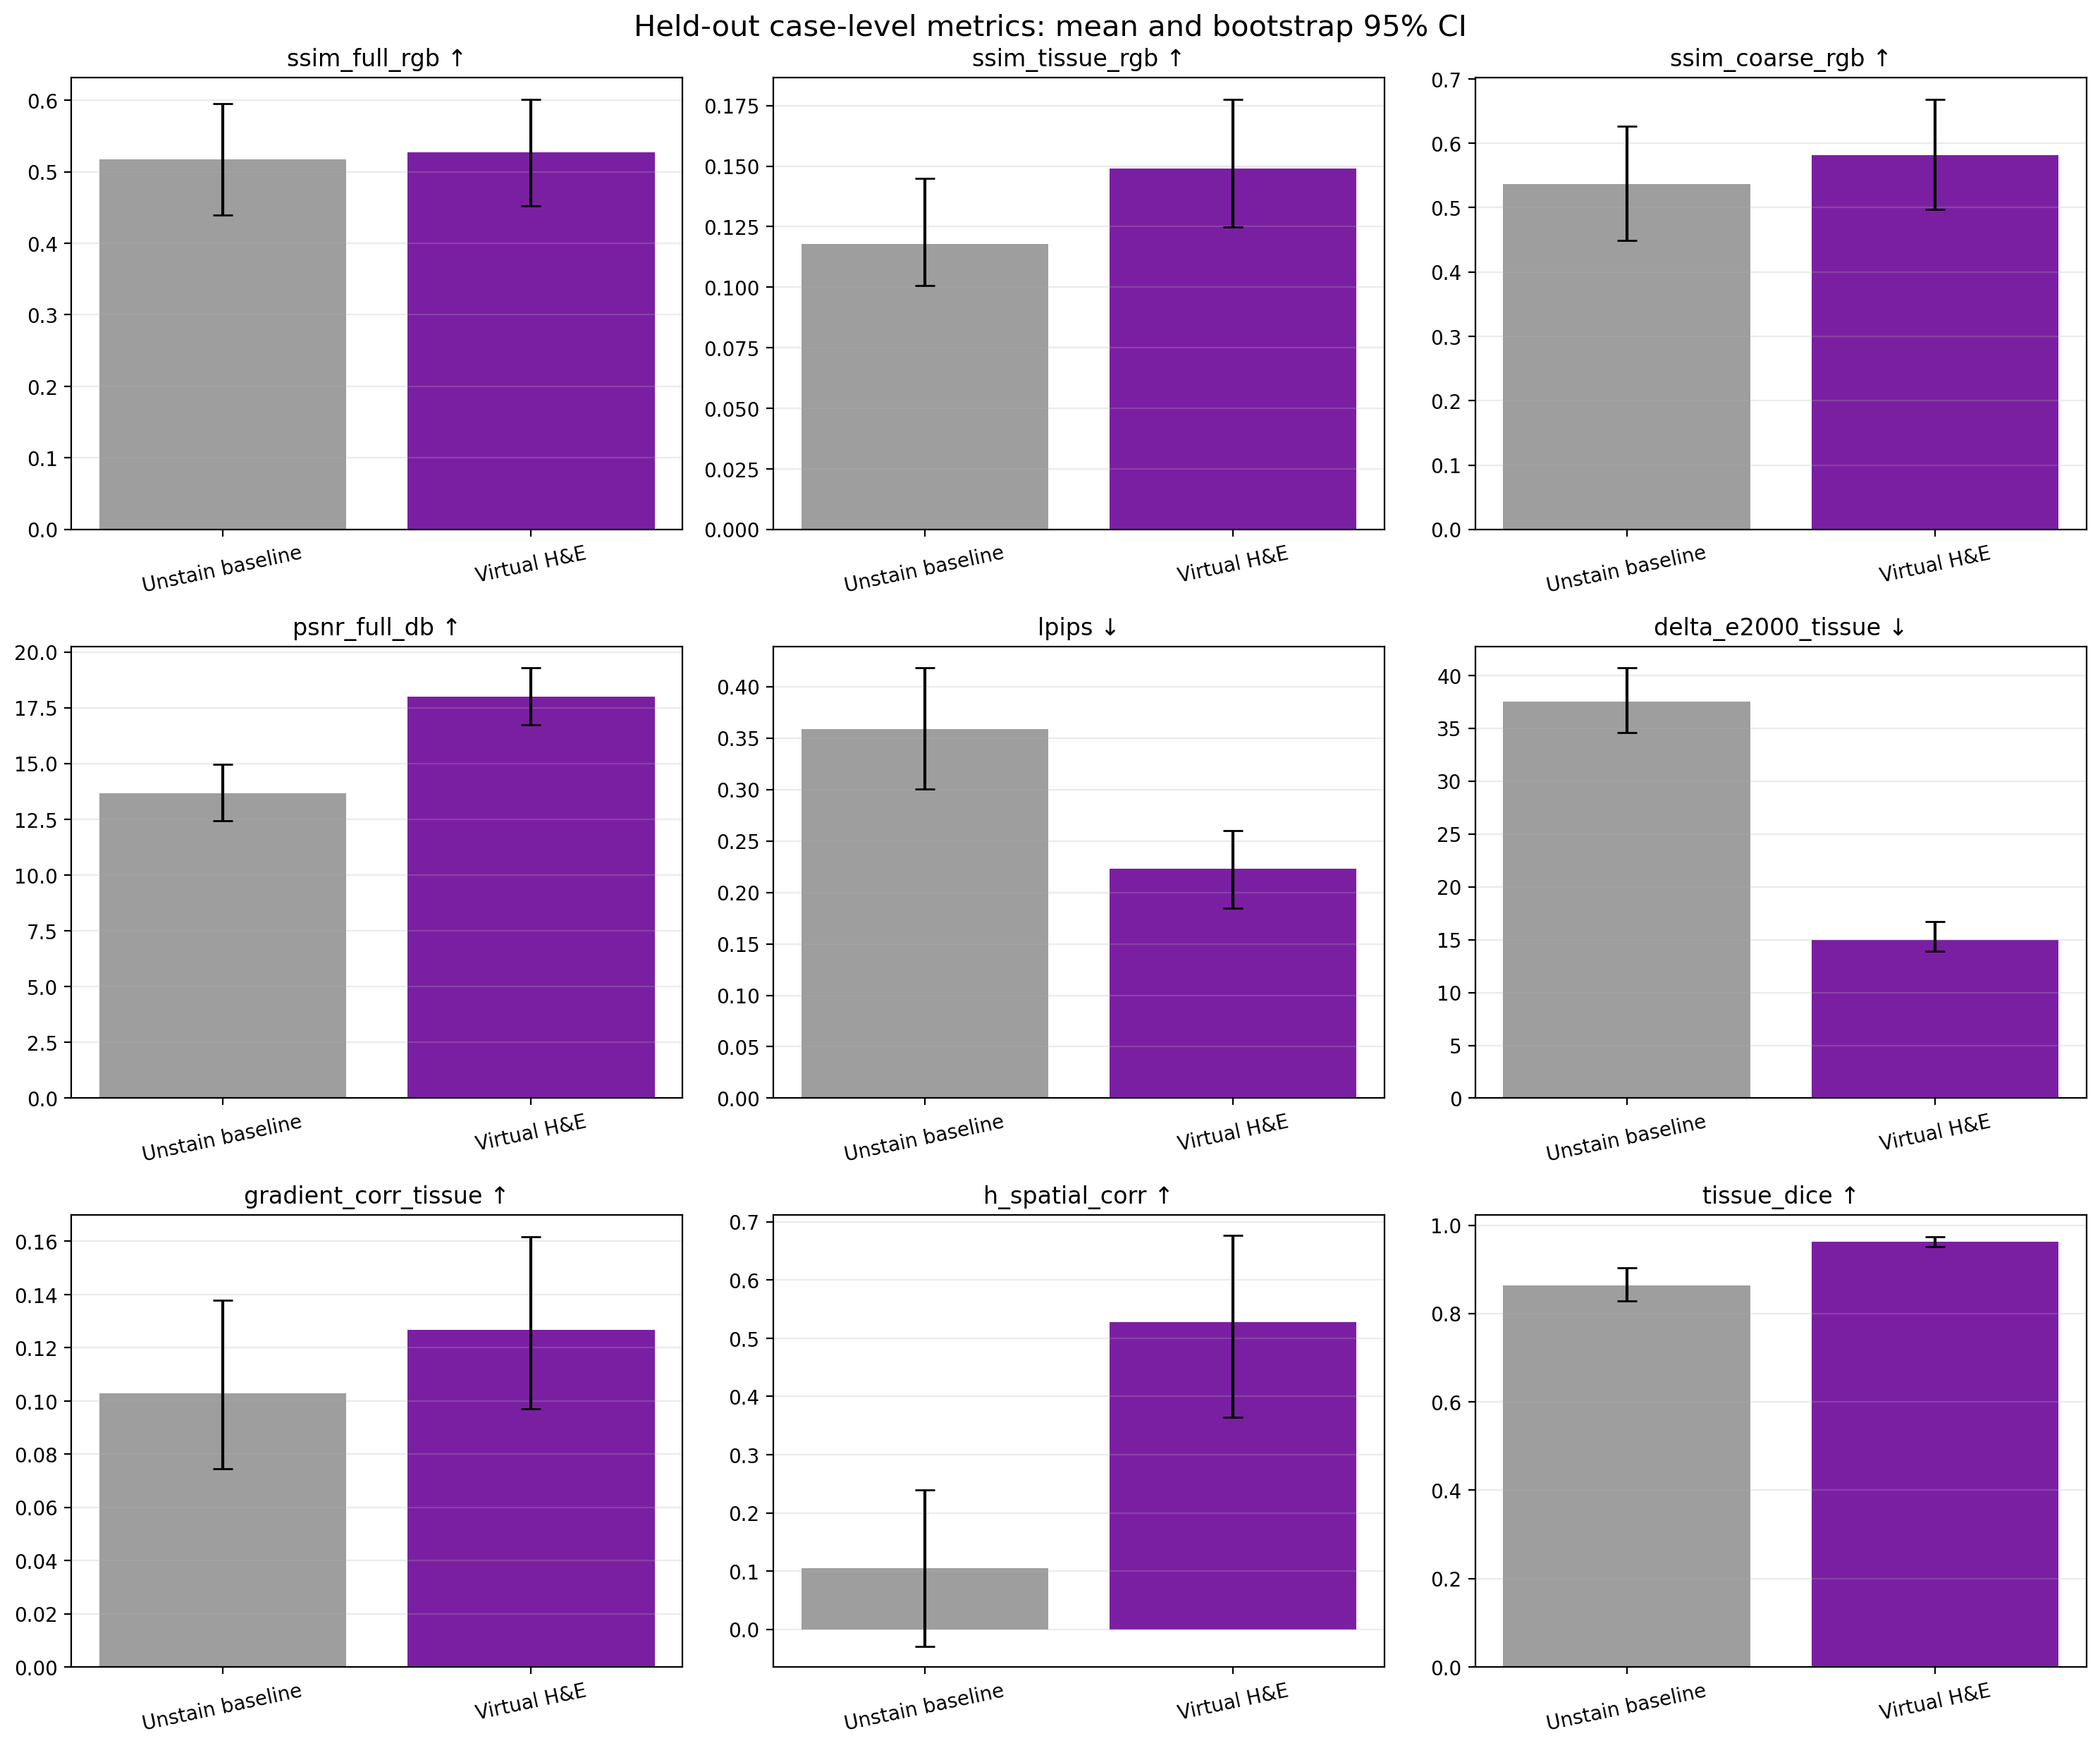

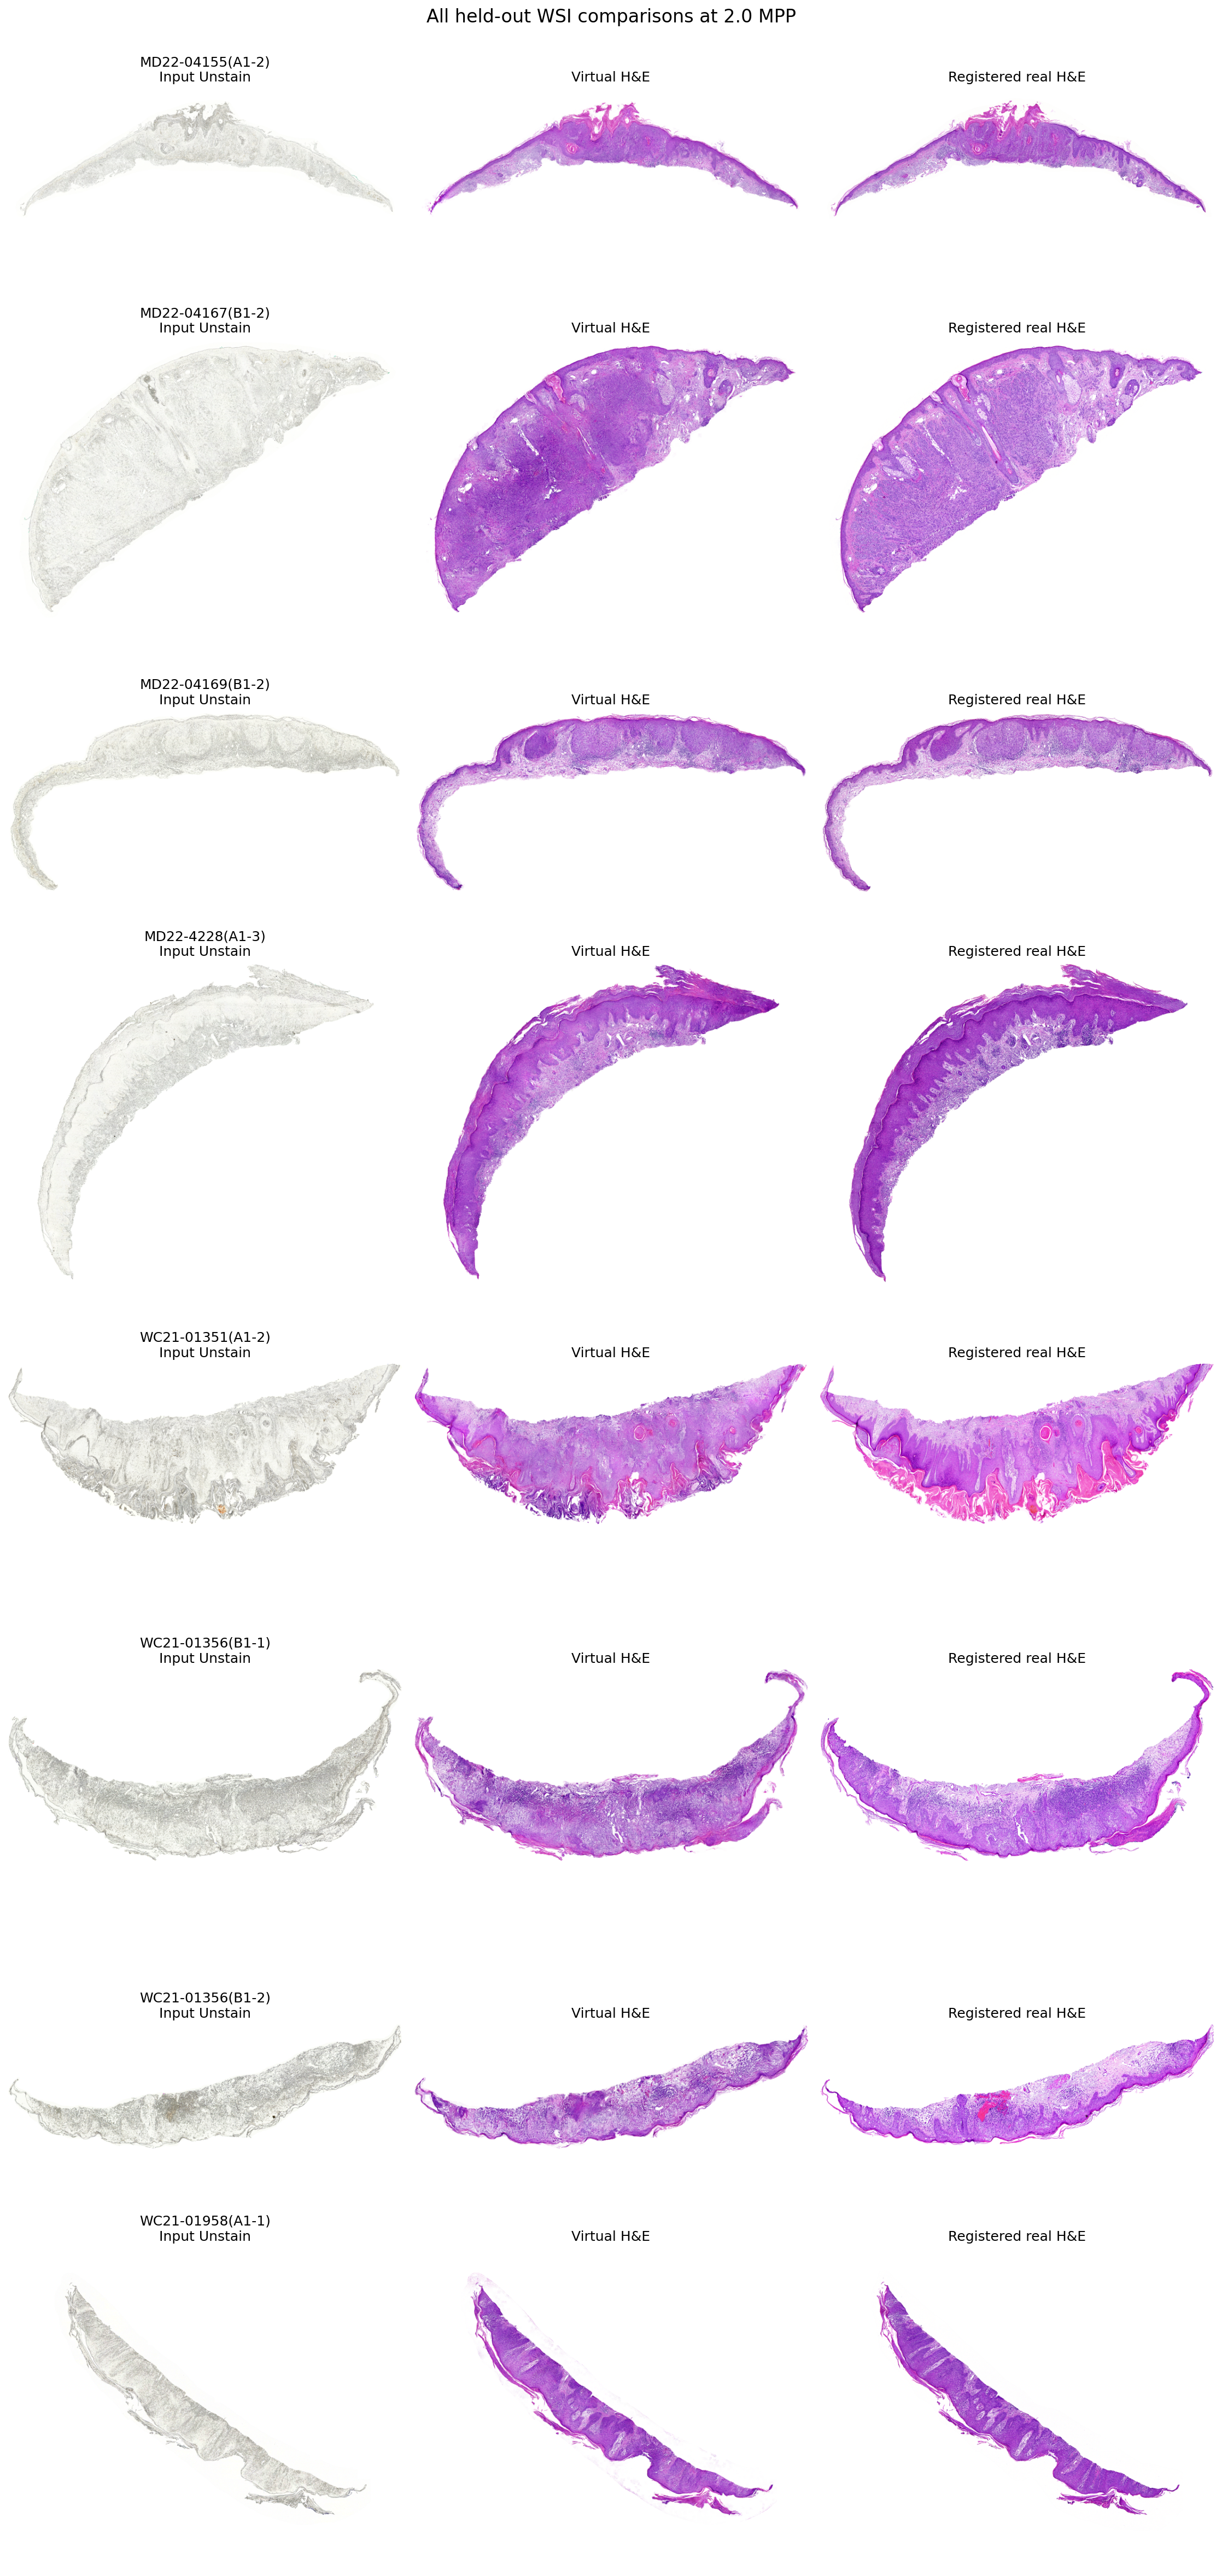

Saved outputs:
run_manifest: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/run_manifest.csv
tile_metrics: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/all_tile_metrics.csv
slide_metrics: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/slide_metrics.csv
case_metrics: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/case_metrics.csv
cohort_summary: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/cohort_metric_summary.csv
cohort_improvement: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/cohort_metric_improvement.csv
qc_slide_metrics: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/qc_passed_slide_metrics.csv
qc_case_metrics: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/qc_passed_case_metrics.csv
qc_cohort_summary: ../../results/Unstain2HnE_two_stage_v4/wsi_test_all_latest_blend256/qc_passed_cohort_metric_summary.csv
qc_coh

In [4]:
primary_summary = results['cohort_summary'].query('metric in @PRIMARY_METRICS')
primary_improvement = results['cohort_improvement'].query('metric in @PRIMARY_METRICS')
display(primary_summary.round(4))
display(primary_improvement.round(4))
print('Registration QC-passed sensitivity analysis (IoU >= 0.90)')
display(results['qc_cohort_summary'].query('metric in @PRIMARY_METRICS').round(4))
display(results['distribution_metrics'].round(4))
display(NotebookImage(filename=str(results['outputs']['cohort_metric_figure'])))
display(NotebookImage(filename=str(results['outputs']['cohort_overview'])))
print('Saved outputs:')
for name, path in results['outputs'].items():
    print(f'{name}: {path}')